# Week 2 class

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from social_networks.describe import describe_graph
import social_networks.visualize as viz

%matplotlib widget

%load_ext autoreload
%autoreload 2

# Video - Clustering Coefficient

## Clustering coefficient



C has 4 friends.
$$\frac{4 \times (4 - 1)}{2} = 6 = \text{num pairs of C's friends}$$

2 pairs of friends are also connected

Local clustering coefficient = 

\begin{aligned}
&= \frac{\text{\# pairs of C's friends who are friend}}{\text{\# of pairs of C's friends}} \\
&= \frac{2}{6} \\
&= \frac{1}{3}
\end{aligned}




Question

$$d_h = 4 \\
\frac{4 \times (4 - 1)}{2} = 6 = \text{num pairs of friends} \\
3 = \text{num pairs of friends that are friends} \\
\frac{3}{6} = \text{clustering coeff}$$

In [128]:
def draw_graph(g):
    plt.figure(figsize=(8,6))
    nx.draw(g, 
            with_labels=True,
            node_color='skyblue', 
            edge_color='gray', 
            node_size=800)
    plt.show()

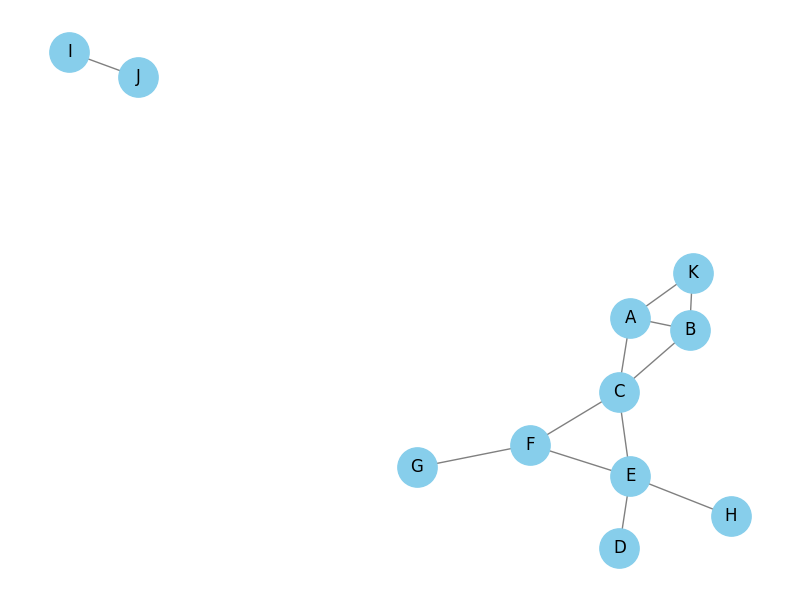

In [129]:
edges = [('A', 'K'), ('A', 'B'), ('A', 'C'),
         ('B', 'C'), ('B', 'K'),
         ('C', 'E'), ('C', 'F'),
         ('D', 'E'), 
         ('E', 'F'), ('E', 'H'),
         ('F', 'G'), ('I', 'J')]

def create_g()->nx.Graph:
    G = nx.Graph()
    G.add_edges_from(edges)
    return G
G = create_g()
draw_graph(G)

In [130]:
G.edges()

EdgeView([('A', 'K'), ('A', 'B'), ('A', 'C'), ('K', 'B'), ('B', 'C'), ('C', 'E'), ('C', 'F'), ('E', 'D'), ('E', 'F'), ('E', 'H'), ('F', 'G'), ('I', 'J')])

In [131]:
G = create_g()
nx.draw(G)

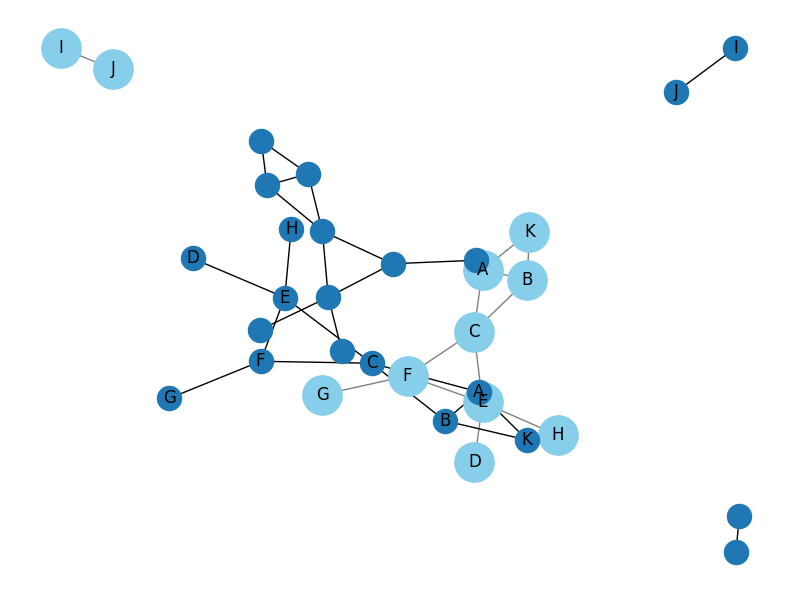

In [132]:
nx.draw(G, with_labels=True)
plt.show()

In [133]:
nx.clustering(G, 'F')

0.3333333333333333

In [134]:
nx.clustering(G, 'A')

0.6666666666666666

In [135]:
nx.clustering(G, 'J')

0

## Plot the graph

### Plot with plotly

In [136]:
# G = nx.karate_club_graph()
pos = nx.spring_layout(G)

edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(x=edge_x, y=edge_y,
                        line=dict(width=0.5, color='#888'),
                        hoverinfo='none',
                        mode='lines')

node_x=[]
node_y = []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

node_trace = go.Scatter(x=node_x, y=node_y,
                        mode='markers+text',
                        text=[str(n) for n in G.nodes()],
                        textposition='top center',
                        hoverinfo='text',
                        marker=dict(showscale=False,
                                    color='skyblue',
                                    size=10,
                                    line_width=2))

fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(showlegend=False,
                                 hovermode='closest',
                                 margin=dict(b=20, l=5, r=5, t=40)))

fig.show()

### Customize matplotlib example

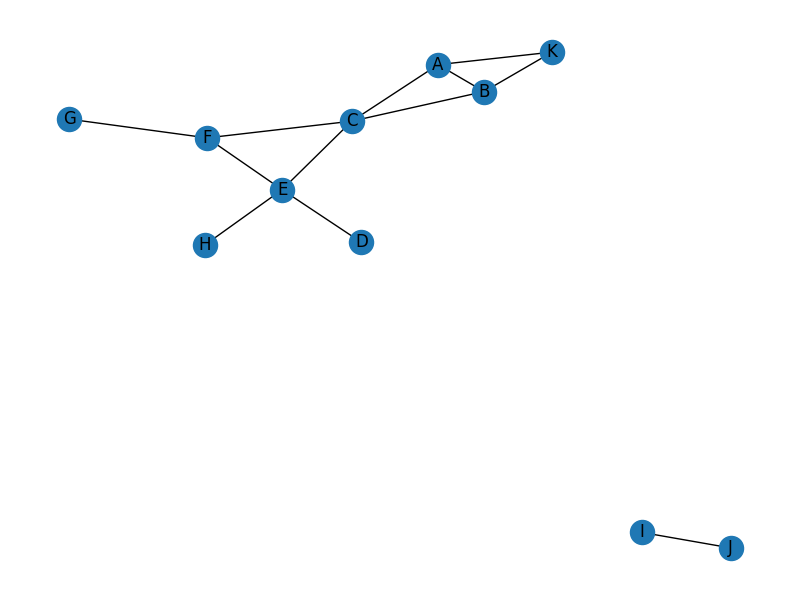

In [137]:
G = nx.Graph()
G.add_edges_from(edges)

# Choose a layout
pos = nx.spring_layout(G, seed=42)

# Draw the graph
plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True)
plt.title('Example')
plt.show()

### Another example

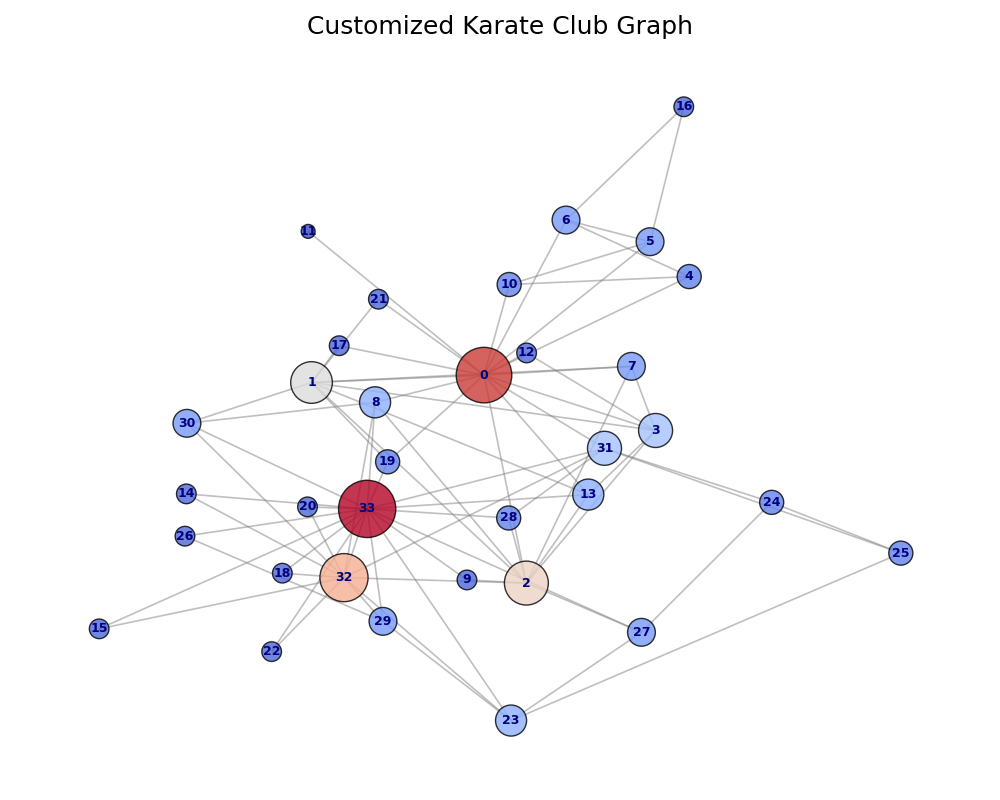

In [138]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.karate_club_graph()
# pos = nx.circular_layout(G)            # nodes in a circle
pos = nx.kamada_kawai_layout(G)      # aesthetically pleasing
# pos = nx.shell_layout(G)             # concentric shells
# pos = nx.spring_layout(G, seed=42)   # force-directed (default)

plt.figure(figsize=(10, 8))

# Node properties
node_sizes = [G.degree[n] * 100 for n in G.nodes()] # Size by degree
node_colors = [G.degree[n] for n in G.nodes()]      # Color by degree

nx.draw_networkx_nodes(G, pos,
                       node_size=node_sizes,
                       node_color=node_colors,
                       cmap=plt.cm.coolwarm,
                       edgecolors='black',
                       alpha=0.8)

# Edge properties
nx.draw_networkx_edges(G, pos,
                       edge_color='gray',
                       width=1.2,
                       alpha=0.5)

# Labels
nx.draw_networkx_labels(G, pos,
                        font_size=9,
                        font_color='navy',
                        font_weight='bold')

# Final plot
plt.title("Customized Karate Club Graph", fontsize=18)
plt.axis('off')
plt.tight_layout()
plt.show()


### Add hover functionality

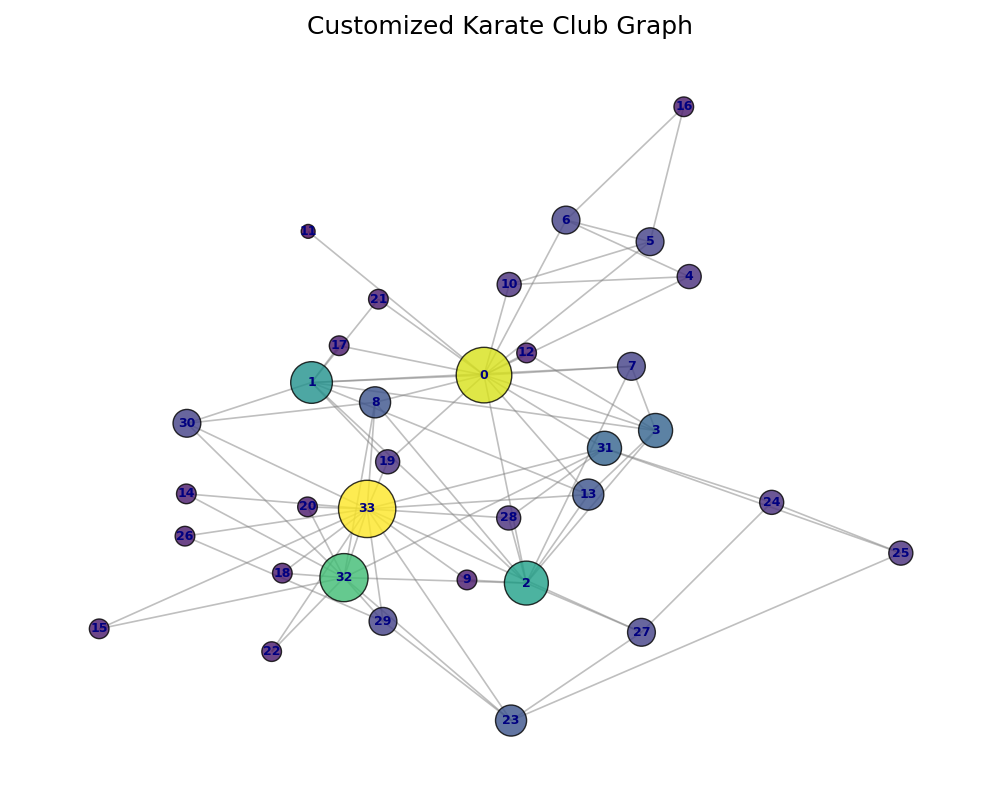

In [139]:
import networkx as nx
import matplotlib.pyplot as plt
import mplcursors

G = nx.karate_club_graph()
# pos = nx.circular_layout(G)            # nodes in a circle
pos = nx.kamada_kawai_layout(G)      # aesthetically pleasing
# pos = nx.shell_layout(G)             # concentric shells
# pos = nx.spring_layout(G, seed=42)   # force-directed (default)

# Plot
fix, ax = plt.subplots(figsize=(10, 8))

# Node properties
node_sizes = [G.degree[n] * 100 for n in G.nodes()] # Size by degree
node_colors = [G.degree[n] for n in G.nodes()]      # Color by degree

# Draw nodes
nodes = nx.draw_networkx_nodes(G, pos,
                       node_size=node_sizes,
                       node_color=node_colors,
                       cmap=plt.cm.viridis,
                       edgecolors='black',
                       alpha=0.8)

# Edge properties
nx.draw_networkx_edges(G, pos, ax=ax,
                       edge_color='gray',
                       width=1.2,
                       alpha=0.5)

# Labels
nx.draw_networkx_labels(G, pos, ax=ax,
                        font_size=9,
                        font_color='navy',
                        font_weight='bold')

# Final plot
plt.title("Customized Karate Club Graph", fontsize=18)
plt.axis('off')

# Add hover tooltips
cursor = mplcursors.cursor(nodes, hover=True)

@cursor.connect('add')
def on_add(sel):
    node_index = sel.index
    node_id = list(G.nodes())[node_index]
    sel.annotation.set_text(f"Node {node_id}\nDegree: {G.degree[node_id]}")
    sel.annotation.get_bbox_patch().set(fc='lightyellow', alpha=0.9)

plt.tight_layout()
plt.show()


## Global clustering coefficient

In [140]:
G = create_g()

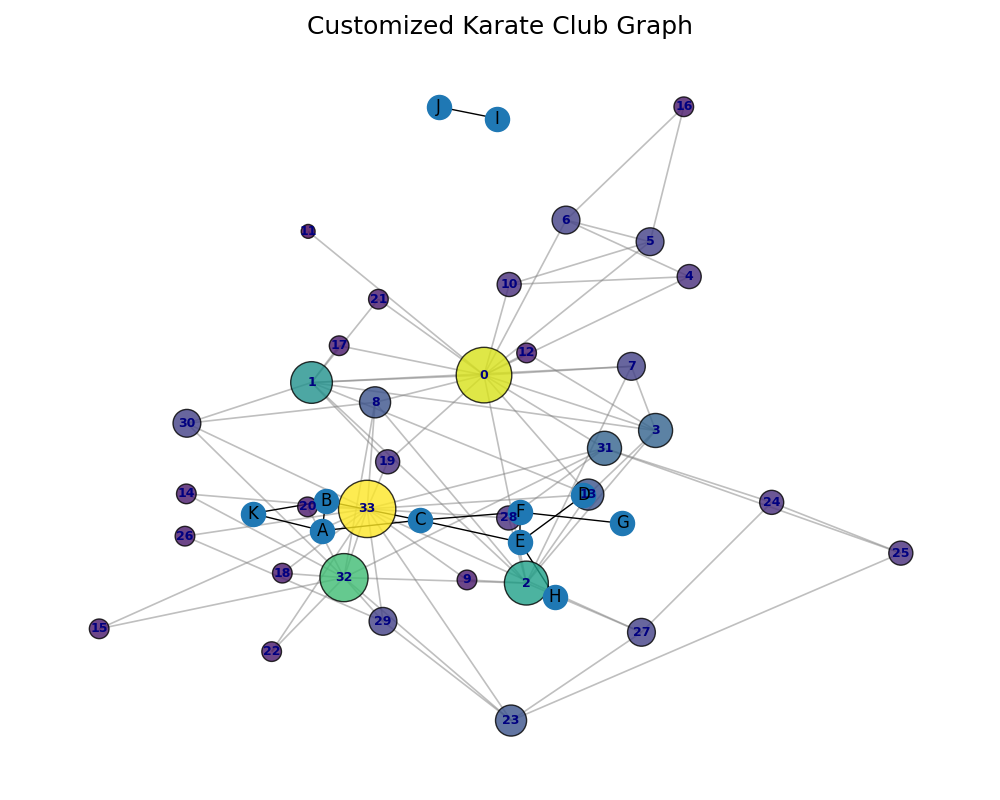

In [141]:
nx.draw(G, with_labels=True)
plt.show()

In [142]:
nx.average_clustering(G)

0.28787878787878785

## Transitivity

$$\text{Transitivity} = \frac{3 \times \text{Num closed triads}}{\text{Num open triads}}$$

In [143]:
nx.transitivity(G)

0.4090909090909091

# Video - Distance Measures

## Distance - How far is node A from node H?

Distance is shortest path between 2 nodes

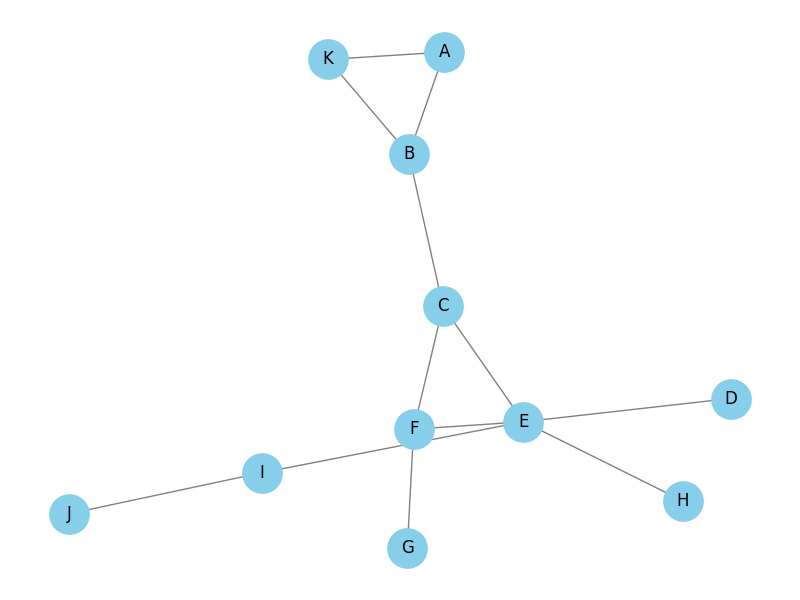

In [64]:
edges_2 = [('A', 'K'), ('A', 'B'),
         ('B', 'C'), ('B', 'K'),
         ('C', 'E'), ('C', 'F'),
         ('D', 'E'), 
         ('E', 'F'), ('E', 'H'), ('E', 'I'),
         ('F', 'G'), ('I', 'J')]

def create_g2()->nx.Graph:
    g = nx.Graph()
    g.add_edges_from(edges_2)
    return g
G2 = create_g2()
draw_graph(G2)

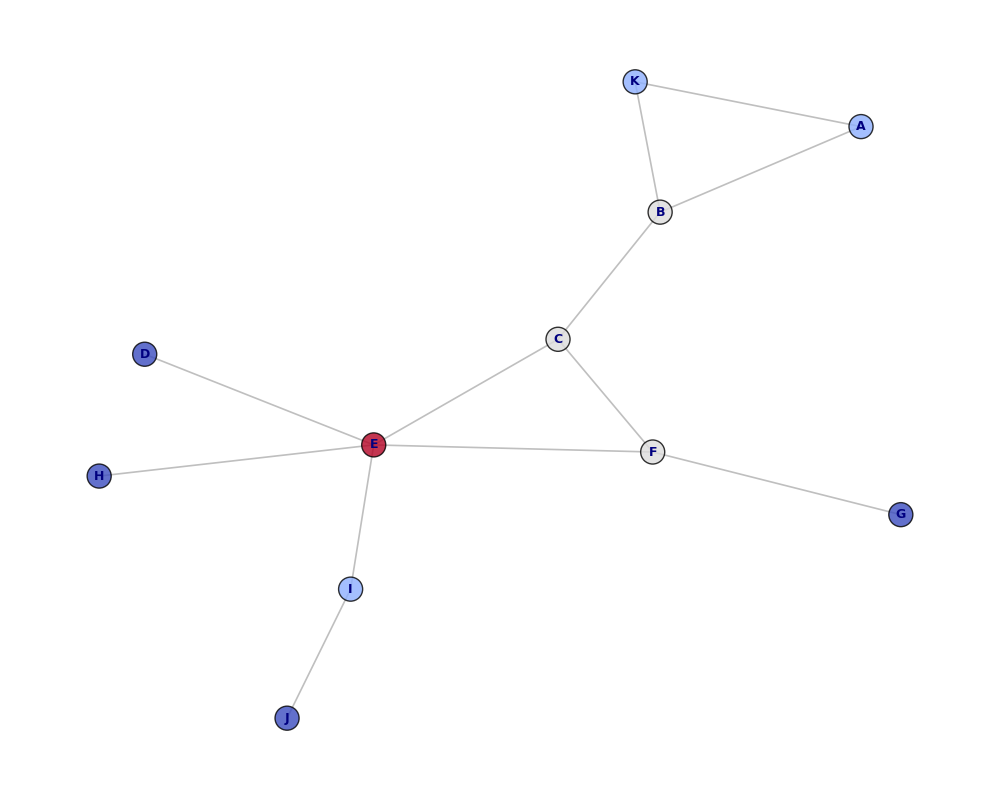

In [115]:
_ = viz.draw_pretty_hover(G2, color_by_degree=True)

In [79]:
nx.shortest_path(G2, 'A', 'H')

['A', 'B', 'C', 'E', 'H']

In [80]:
nx.shortest_path_length(G2, 'A', 'H')

4

## Find distance to all other nodes

### BFS (Breadth First Search)

In [81]:
T = nx.bfs_tree(G2, 'A')

In [82]:
T.edges()

OutEdgeView([('A', 'K'), ('A', 'B'), ('B', 'C'), ('C', 'E'), ('C', 'F'), ('E', 'D'), ('E', 'H'), ('E', 'I'), ('F', 'G'), ('I', 'J')])

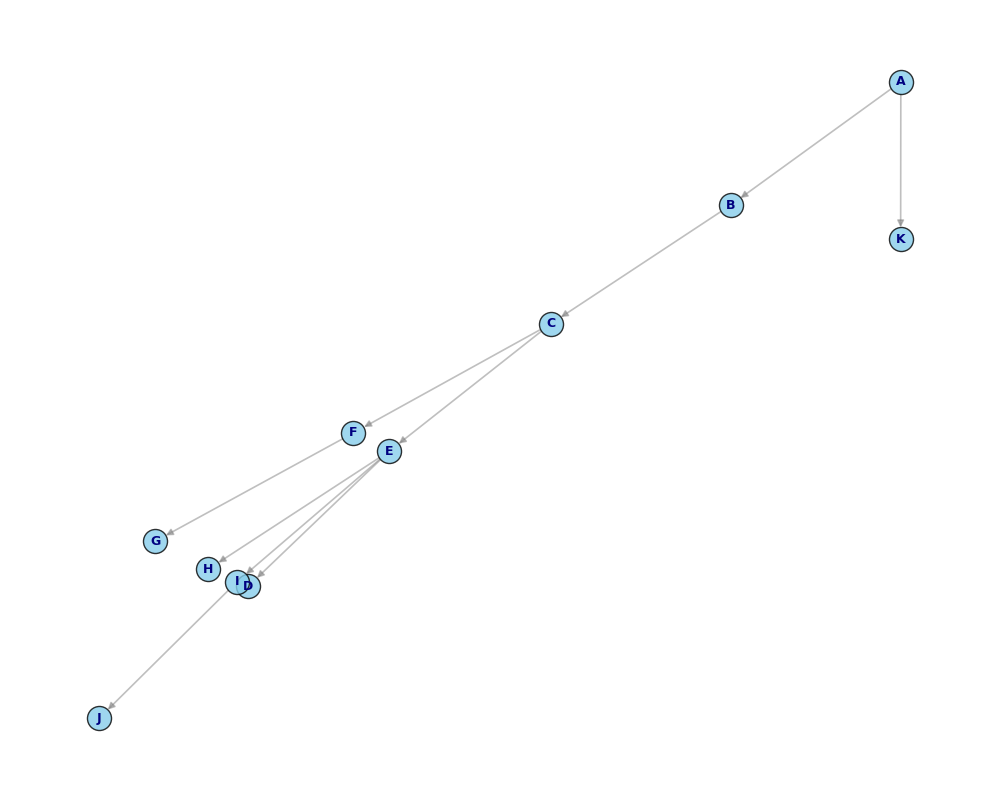

In [116]:
viz.draw_pretty_hover(T);

In [86]:
nx.shortest_path_length(G2, 'A')

{'A': 0,
 'K': 1,
 'B': 1,
 'C': 2,
 'E': 3,
 'F': 3,
 'D': 4,
 'H': 4,
 'I': 4,
 'G': 4,
 'J': 5}

### Average distance

In [87]:
nx.average_shortest_path_length(G2)

2.5272727272727273

### Max distance between 2 nodes (Diameter)

In [88]:
nx.diameter(G2)

5

### Eccentricity

The largest distance between _n_ and all other nodes

In [90]:
nx.eccentricity(G2)

{'A': 5,
 'K': 5,
 'B': 4,
 'C': 3,
 'E': 3,
 'F': 3,
 'D': 4,
 'H': 4,
 'I': 4,
 'G': 4,
 'J': 5}

### Radius - Minimum eccentricity

In [92]:
nx.radius(G2)

3

### Periphery

The set of nodes in the graph that have an eccentricity equal to the diameter

In [94]:
nx.periphery(G2)

['A', 'K', 'J']

### Center

Set of nodes that have an eccentricity equal to the radius

In [95]:
nx.center(G2)

['C', 'E', 'F']

## Karate Club Network

In [97]:
G = nx.karate_club_graph()

In [98]:
G = nx.convert_node_labels_to_integers(G, first_label=1)

In [112]:
_ = describe_graph(G)

{
    'avg_shortest_path': 2.408199643493761,
    'radius': 3,
    'diameter': 5,
    'center': [1, 2, 3, 4, 9, 14, 20, 32],
    'periphery': [15, 16, 17, 19, 21, 23, 24, 27, 30]
}

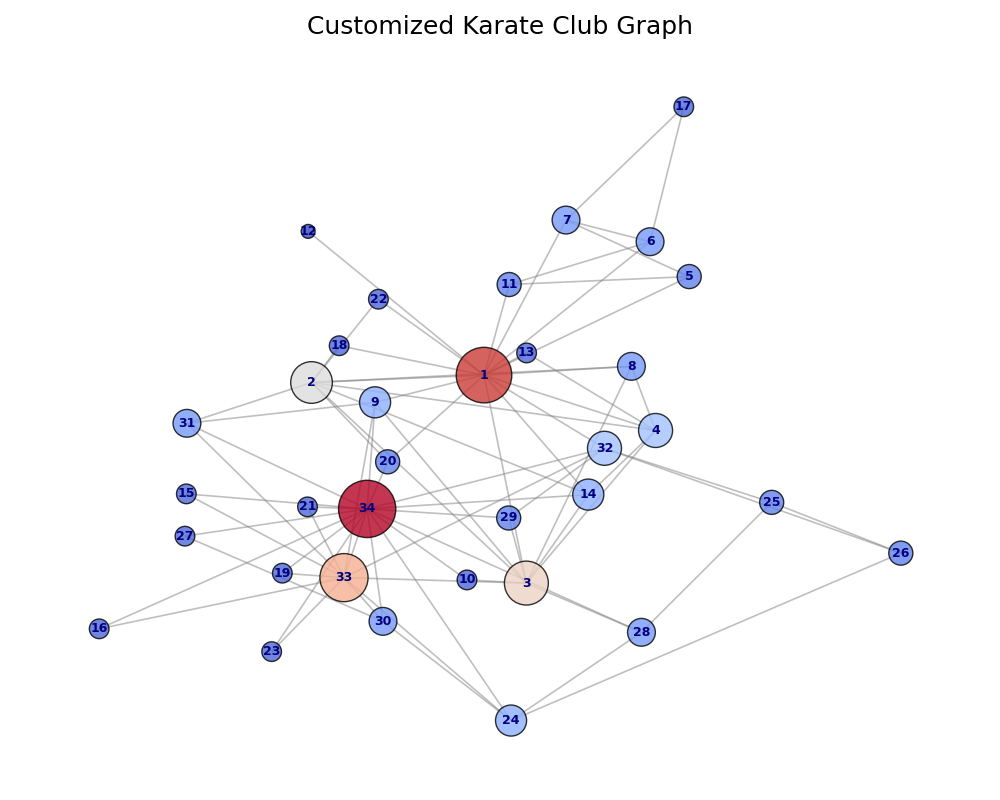

In [109]:
viz.draw_pretty_hover(G, color_by_degree=True, scale_by_degree=True);

# Video - Connected Components

# Video - Network Robustness

Newtork Robustness  
The ability of a network to maintain its general structural properties when it faces failures or attacks

In [117]:
import networkx as nx 

G = nx.DiGraph()
G.add_edges_from([('A', 'B'), ('C', 'A'), ('A', 'E'), ('G', 'A'), ('A', 'N'), ('B', 'C'), ('D', 'B'), ('B', 'E'), ('C', 'D'), ('E', 'C'), ('D', 'E'), ('E', 'D'), ('F', 'G'), ('I', 'F'), ('J', 'F'), ('H', 'G'), ('I', 'G'), ('G', 'J'), ('I', 'H'), ('H', 'I'), ('I', 'J'), ('J', 'O'), ('O', 'J'), ('K', 'M'), ('K', 'L'), ('O', 'K'), ('O', 'L'), ('N', 'L'), ('L', 'M'), ('N', 'O')])


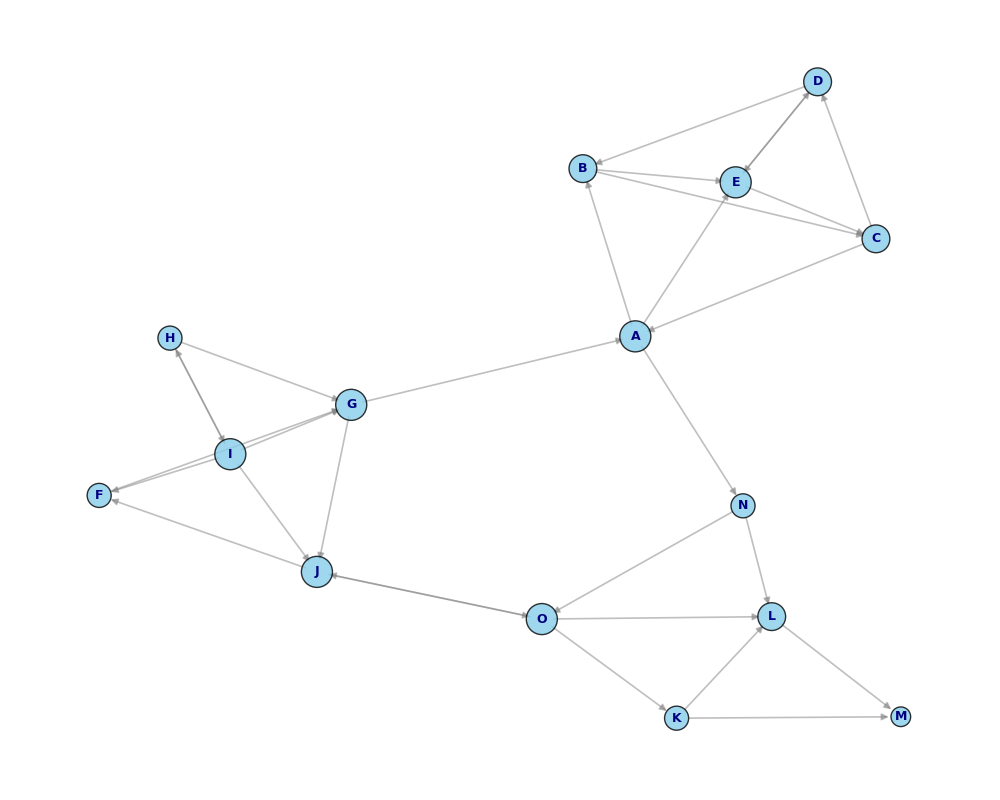

In [119]:
viz.draw_pretty_hover(G, scale_by_degree=True);

## Edge connectivity

In [121]:
nx.edge_connectivity(G, 'H', 'O')

2

Which edges do I need to remove to block a message from H to O

In [122]:
nx.minimum_edge_cut(G, 'H', 'O')

{('J', 'O'), ('N', 'O')}

## Useful functions

Graphs with large node and edge connectivity are more robust to the loss of nodes and edges

### Node connectivity

In [124]:
nx.node_connectivity(G, 'G', 'L')

2

In [125]:
nx.minimum_node_cut(G, 'G', 'L')

{'N', 'O'}

### Edge connectivity

In [126]:
nx.edge_connectivity(G, 'G', 'L')

2

In [127]:
nx.minimum_edge_cut(G, 'G', 'L')

{('A', 'N'), ('J', 'O')}